In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from math import radians
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from cw.context import time_it
from cw.simulation import Simulation, StatesBase, AB3Integrator, ModuleBase, Logging
from pypole.pole import Pole
from pypole.pid_agent import PIDAgent

In [3]:
@dataclass
class States(StatesBase):
    t: float = 0
    theta: float = radians(2)
    theta_dot: float = 0
    theta_dot_dot: float = 0
    torque: float = 0
    reward: float = 0
    agent_torque: float = 0
        
    def get_y_dot(self):
        return np.array([
            self.theta_dot, 
            self.theta_dot_dot
        ], dtype=np.float)

    def get_y(self):
        return np.array([
            self.theta, 
            self.theta_dot
        ], dtype=np.float)

    def set_t_y(self, t, y):
        self.t = t
        self.theta = y[0]
        self.theta_dot = y[1]
        

In [18]:
simulation = Simulation(
    states_class=States,
    integrator=AB3Integrator(
        h=0.01,
        rk4=False,
        fd_max_order=1),
    modules=[
        PIDAgent(k_p=10, k_i=1, k_d=1),
        Pole(
            mass=1,
            length=1,
            theta_terminate=None,
            theta_min_reward=None,
        ),
    ],
    logging=Logging(),
    initial_state_values=None,
)
simulation.initialize()

In [21]:
simulation.states.theta = 0.1
simulation.states.theta_dot = 0

with time_it("simulation run"):
    result = simulation.run(1000)

simulation run: 0.046384303001104854 [s]


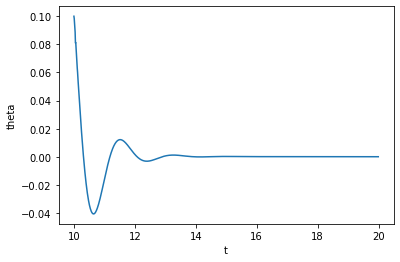

In [22]:
result.theta.plot()

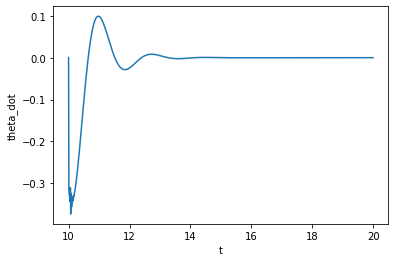

In [26]:
result.theta_dot.plot()